In [1]:
import zipfile
import os
import shutil

zip_file_path = '/content/Multiple Sclerosis - classes.zip'
extract_path = '/content/ms_classes'

# Remove the extraction path if it already exists
if os.path.exists(extract_path):
    shutil.rmtree(extract_path)

# Extract the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Extracted data to: {extract_path}")

Extracted data to: /content/ms_classes


In [16]:
!pip install imbalanced-learn opencv-python scikit-learn
!pip install tensorflow

In [17]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np

train_dir = '/content/balanced_ms_classes/train'
val_dir = '/content/balanced_ms_classes/val'
test_dir = '/content/balanced_ms_classes/test'
classes = ['AD_MildDemented', 'AD_ModerateDemented', 'AD_VeryMildDemented',
           'BT_glioma', 'BT_meningioma', 'BT_pituitary', 'MS', 'Normal']
num_classes = len(classes)
img_size = (224, 224)
batch_size = 32

print(f"Using {num_classes} classes. Image size: {img_size}")

Using 8 classes. Image size: (224, 224)


In [18]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    classes=classes
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    classes=classes
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    classes=classes,
    shuffle=False  # For consistent eval
)

print(f"Train batches: {train_generator.samples // batch_size}")
print(f"Val batches: {val_generator.samples // batch_size}")
print(f"Test batches: {test_generator.samples // batch_size}")

Found 44192 images belonging to 8 classes.
Found 1639 images belonging to 8 classes.
Found 1640 images belonging to 8 classes.
Train batches: 1381
Val batches: 51
Test batches: 51


In [19]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(*img_size, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,047,240 (11.62 MB)

 Trainable params: 789,256 (3.01 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [20]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=7, min_lr=1e-7, verbose=1),
    ModelCheckpoint('/content/best_mobilenet_model.h5', monitor='val_loss', save_best_only=True, verbose=1)
]

print("Enhanced callbacks ready: EarlyStopping (patience=15 on val_loss), LR Reduce, Checkpoint")

Enhanced callbacks ready: EarlyStopping (patience=15 on val_loss), LR Reduce, Checkpoint


In [21]:
epochs = 50

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epochs,
    validation_data=val_generator,
    validation_steps=val_generator.samples // batch_size,
    callbacks=callbacks
)

print("Initial training complete! Early stopping activated if needed.")

Epoch 1/50
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.5551 - loss: 1.0732
Epoch 1: val_loss improved from inf to 0.92917, saving model to /content/best_mobilenet_model.h5


1381/1381 ━━━━━━━━━━━━━━━━━━━━ 406s 292ms/step - accuracy: 0.5552 - loss: 1.0731 - val_accuracy: 0.5772 - val_loss: 0.9292 - learning_rate: 0.0010
Epoch 2/50
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.7020 - loss: 0.7050
Epoch 2: val_loss improved from 0.92917 to 0.79515, saving model to /content/best_mobilenet_model.h5


1381/1381 ━━━━━━━━━━━━━━━━━━━━ 414s 300ms/step - accuracy: 0.7020 - loss: 0.7050 - val_accuracy: 0.6017 - val_loss: 0.7952 - learning_rate: 0.0010
Epoch 3/50
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.7224 - loss: 0.6476
Epoch 3: val_loss improved from 0.79515 to 0.70286, saving model to /content/best_mobilenet_model.h5


1381/1381 ━━━━━━━━━━━━━━━━━━━━ 436s 316ms/step - accuracy: 0.7224 - loss: 0.6476 - val_accuracy: 0.6599 - val_loss: 0.7029 - learning_rate: 0.0010
Epoch 4/50
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.7382 - loss: 0.6126
Epoch 4: val_loss did not improve from 0.70286
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 431s 312ms/step - accuracy: 0.7382 - loss: 0.6126 - val_accuracy: 0.5956 - val_loss: 0.7602 - learning_rate: 0.0010
Epoch 5/50
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.7492 - loss: 0.5889
Epoch 5: val_loss improved from 0.70286 to 0.69999, saving model to /content/best_mobilenet_model.h5


1381/1381 ━━━━━━━━━━━━━━━━━━━━ 433s 313ms/step - accuracy: 0.7492 - loss: 0.5889 - val_accuracy: 0.6771 - val_loss: 0.7000 - learning_rate: 0.0010
Epoch 6/50
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.7566 - loss: 0.5727
Epoch 6: val_loss improved from 0.69999 to 0.66332, saving model to /content/best_mobilenet_model.h5


...

1381/1381 ━━━━━━━━━━━━━━━━━━━━ 409s 296ms/step - accuracy: 0.7802 - loss: 0.5206 - val_accuracy: 0.6869 - val_loss: 0.6244 - learning_rate: 0.0010
Epoch 12/50
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.7841 - loss: 0.5158
Epoch 12: val_loss improved from 0.62443 to 0.61940, saving model to /content/best_mobilenet_model.h5


1381/1381 ━━━━━━━━━━━━━━━━━━━━ 417s 302ms/step - accuracy: 0.7841 - loss: 0.5158 - val_accuracy: 0.6857 - val_loss: 0.6194 - learning_rate: 0.0010
Epoch 13/50
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.7851 - loss: 0.5005
Epoch 13: val_loss did not improve from 0.61940
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 416s 301ms/step - accuracy: 0.7851 - loss: 0.5005 - val_accuracy: 0.7034 - val_loss: 0.6226 - learning_rate: 0.0010
Epoch 14/50
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.7804 - loss: 0.5128
Epoch 14: val_loss improved from 0.61940 to 0.57296, saving model to /content/best_mobilenet_model.h5


1381/1381 ━━━━━━━━━━━━━━━━━━━━ 425s 308ms/step - accuracy: 0.7805 - loss: 0.5128 - val_accuracy: 0.7273 - val_loss: 0.5730 - learning_rate: 0.0010
Epoch 15/50
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.7871 - loss: 0.4948
Epoch 15: val_loss did not improve from 0.57296
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 423s 306ms/step - accuracy: 0.7871 - loss: 0.4948 - val_accuracy: 0.6569 - val_loss: 0.6677 - learning_rate: 0.0010
Epoch 16/50
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.7940 - loss: 0.4914
Epoch 16: val_loss did not improve from 0.57296
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 425s 308ms/step - accuracy: 0.7940 - loss: 0.4914 - val_accuracy: 0.7138 - val_loss: 0.6217 - learning_rate: 0.0010
Epoch 17/50
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.7934 - loss: 0.4784
Epoch 17: val_loss improved from 0.57296 to 0.56859, saving model to /content/best_mobilenet_model.h5


1381/1381 ━━━━━━━━━━━━━━━━━━━━ 408s 295ms/step - accuracy: 0.7934 - loss: 0.4785 - val_accuracy: 0.7316 - val_loss: 0.5686 - learning_rate: 0.0010
Epoch 18/50
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.7942 - loss: 0.4797
Epoch 18: val_loss did not improve from 0.56859
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 424s 307ms/step - accuracy: 0.7942 - loss: 0.4797 - val_accuracy: 0.6820 - val_loss: 0.6268 - learning_rate: 0.0010
Epoch 19/50
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.7967 - loss: 0.4830
Epoch 19: val_loss did not improve from 0.56859
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 412s 298ms/step - accuracy: 0.7967 - loss: 0.4830 - val_accuracy: 0.7304 - val_loss: 0.5827 - learning_rate: 0.0010
Epoch 20/50
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.7982 - loss: 0.4749
Epoch 20: val_loss improved from 0.56859 to 0.53501, saving model to /content/best_mobilenet_model.h5


1381/1381 ━━━━━━━━━━━━━━━━━━━━ 408s 295ms/step - accuracy: 0.7982 - loss: 0.4749 - val_accuracy: 0.7518 - val_loss: 0.5350 - learning_rate: 0.0010
Epoch 21/50
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.7977 - loss: 0.4747
Epoch 21: val_loss did not improve from 0.53501
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 413s 299ms/step - accuracy: 0.7977 - loss: 0.4747 - val_accuracy: 0.7047 - val_loss: 0.6030 - learning_rate: 0.0010
Epoch 22/50
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.7948 - loss: 0.4780
Epoch 22: val_loss did not improve from 0.53501
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 422s 305ms/step - accuracy: 0.7948 - loss: 0.4780 - val_accuracy: 0.6152 - val_loss: 0.7372 - learning_rate: 0.0010
Epoch 23/50
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.8027 - loss: 0.4711
Epoch 23: val_loss did not improve from 0.53501
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 421s 305ms/step - accuracy: 0.8027 - loss: 0.4711 - val_accuracy: 0.6728 - val_loss: 0.6244 - learning_rate: 0.

In [22]:
base_model.trainable = True
fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_epochs = 50
total_epochs = epochs + fine_epochs

history_fine = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1],
    validation_data=val_generator,
    validation_steps=val_generator.samples // batch_size,
    callbacks=callbacks  # Uses enhanced early stopping
)

print("Fine-tuning complete! Model saved as /content/best_mobilenet_model.h5")
print(f"Training stopped early if val_loss didn't improve for 15 epochs.")

Epoch 35/100
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.7141 - loss: 0.8533
Epoch 35: val_loss did not improve from 0.53501
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 491s 350ms/step - accuracy: 0.7141 - loss: 0.8531 - val_accuracy: 0.6930 - val_loss: 0.6126 - learning_rate: 1.0000e-04
Epoch 36/100
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.8327 - loss: 0.3968
Epoch 36: val_loss did not improve from 0.53501
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 483s 350ms/step - accuracy: 0.8327 - loss: 0.3968 - val_accuracy: 0.7328 - val_loss: 0.6383 - learning_rate: 1.0000e-04
Epoch 37/100
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.8719 - loss: 0.3188
Epoch 37: val_loss improved from 0.53501 to 0.51855, saving model to /content/best_mobilenet_model.h5


1381/1381 ━━━━━━━━━━━━━━━━━━━━ 464s 336ms/step - accuracy: 0.8719 - loss: 0.3188 - val_accuracy: 0.7911 - val_loss: 0.5185 - learning_rate: 1.0000e-04
Epoch 38/100
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.8966 - loss: 0.2566
Epoch 38: val_loss improved from 0.51855 to 0.41649, saving model to /content/best_mobilenet_model.h5


1381/1381 ━━━━━━━━━━━━━━━━━━━━ 486s 352ms/step - accuracy: 0.8966 - loss: 0.2566 - val_accuracy: 0.8223 - val_loss: 0.4165 - learning_rate: 1.0000e-04
Epoch 39/100
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.9101 - loss: 0.2313
Epoch 39: val_loss did not improve from 0.41649
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 464s 336ms/step - accuracy: 0.9101 - loss: 0.2313 - val_accuracy: 0.8260 - val_loss: 0.4347 - learning_rate: 1.0000e-04
Epoch 40/100
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.9267 - loss: 0.1916
Epoch 40: val_loss improved from 0.41649 to 0.35532, saving model to /content/best_mobilenet_model.h5


1381/1381 ━━━━━━━━━━━━━━━━━━━━ 480s 347ms/step - accuracy: 0.9267 - loss: 0.1916 - val_accuracy: 0.8609 - val_loss: 0.3553 - learning_rate: 1.0000e-04
Epoch 41/100
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.9315 - loss: 0.1751
Epoch 41: val_loss improved from 0.35532 to 0.28593, saving model to /content/best_mobilenet_model.h5


1381/1381 ━━━━━━━━━━━━━━━━━━━━ 459s 332ms/step - accuracy: 0.9315 - loss: 0.1751 - val_accuracy: 0.8744 - val_loss: 0.2859 - learning_rate: 1.0000e-04
Epoch 42/100
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.9424 - loss: 0.1491
Epoch 42: val_loss did not improve from 0.28593
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 487s 352ms/step - accuracy: 0.9424 - loss: 0.1491 - val_accuracy: 0.8707 - val_loss: 0.3012 - learning_rate: 1.0000e-04
Epoch 43/100
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.9478 - loss: 0.1366
Epoch 43: val_loss did not improve from 0.28593
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 494s 358ms/step - accuracy: 0.9478 - loss: 0.1366 - val_accuracy: 0.8419 - val_loss: 0.4361 - learning_rate: 1.0000e-04
Epoch 44/100
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.9553 - loss: 0.1200
Epoch 44: val_loss improved from 0.28593 to 0.28108, saving model to /content/best_mobilenet_model.h5


...

1381/1381 ━━━━━━━━━━━━━━━━━━━━ 497s 360ms/step - accuracy: 0.9821 - loss: 0.0506 - val_accuracy: 0.9369 - val_loss: 0.1671 - learning_rate: 1.0000e-04
Epoch 58/100
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.9841 - loss: 0.0481
Epoch 58: val_loss improved from 0.16713 to 0.15874, saving model to /content/best_mobilenet_model.h5


1381/1381 ━━━━━━━━━━━━━━━━━━━━ 492s 356ms/step - accuracy: 0.9841 - loss: 0.0481 - val_accuracy: 0.9504 - val_loss: 0.1587 - learning_rate: 1.0000e-04
Epoch 59/100
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.9831 - loss: 0.0498
Epoch 59: val_loss did not improve from 0.15874
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 494s 358ms/step - accuracy: 0.9831 - loss: 0.0498 - val_accuracy: 0.9406 - val_loss: 0.1869 - learning_rate: 1.0000e-04
Epoch 60/100
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.9839 - loss: 0.0465
Epoch 60: val_loss did not improve from 0.15874
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 489s 354ms/step - accuracy: 0.9839 - loss: 0.0465 - val_accuracy: 0.9357 - val_loss: 0.2009 - learning_rate: 1.0000e-04
Epoch 61/100
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.9835 - loss: 0.0484
Epoch 61: val_loss did not improve from 0.15874
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 491s 355ms/step - accuracy: 0.9835 - loss: 0.0484 - val_accuracy: 0.9387 - val_loss: 0.1851 - le

1381/1381 ━━━━━━━━━━━━━━━━━━━━ 474s 343ms/step - accuracy: 0.9910 - loss: 0.0270 - val_accuracy: 0.9651 - val_loss: 0.1241 - learning_rate: 2.0000e-05
Epoch 67/100
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.9936 - loss: 0.0195
Epoch 67: val_loss improved from 0.12415 to 0.12372, saving model to /content/best_mobilenet_model.h5


1381/1381 ━━━━━━━━━━━━━━━━━━━━ 494s 357ms/step - accuracy: 0.9936 - loss: 0.0195 - val_accuracy: 0.9583 - val_loss: 0.1237 - learning_rate: 2.0000e-05
Epoch 68/100
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.9930 - loss: 0.0195
Epoch 68: val_loss improved from 0.12372 to 0.10328, saving model to /content/best_mobilenet_model.h5


1381/1381 ━━━━━━━━━━━━━━━━━━━━ 502s 363ms/step - accuracy: 0.9930 - loss: 0.0195 - val_accuracy: 0.9645 - val_loss: 0.1033 - learning_rate: 2.0000e-05
Epoch 69/100
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.9946 - loss: 0.0159
Epoch 69: val_loss did not improve from 0.10328
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 481s 348ms/step - accuracy: 0.9946 - loss: 0.0159 - val_accuracy: 0.9657 - val_loss: 0.1177 - learning_rate: 2.0000e-05
Epoch 70/100
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.9944 - loss: 0.0171
Epoch 70: val_loss did not improve from 0.10328
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 489s 354ms/step - accuracy: 0.9944 - loss: 0.0171 - val_accuracy: 0.9626 - val_loss: 0.1349 - learning_rate: 2.0000e-05
Epoch 71/100
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.9952 - loss: 0.0134
Epoch 71: val_loss did not improve from 0.10328
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 473s 342ms/step - accuracy: 0.9952 - loss: 0.0134 - val_accuracy: 0.9620 - val_loss: 0.1291 - le

51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 149ms/step - accuracy: 0.9701 - loss: 0.0991
Test Accuracy: 0.9657
Test Loss: 0.1078
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 160ms/step
                     precision    recall  f1-score   support

    AD_MildDemented       0.99      1.00      0.99        90
AD_ModerateDemented       1.00      1.00      1.00         6
AD_VeryMildDemented       0.97      0.95      0.96       224
          BT_glioma       0.99      0.97      0.98       162
      BT_meningioma       0.97      0.97      0.97       153
       BT_pituitary       0.99      1.00      0.99       174
                 MS       0.90      0.91      0.90       141
             Normal       0.96      0.97      0.96       690

           accuracy                           0.97      1640
          macro avg       0.97      0.97      0.97      1640
       weighted avg       0.97      0.97      0.97      1640



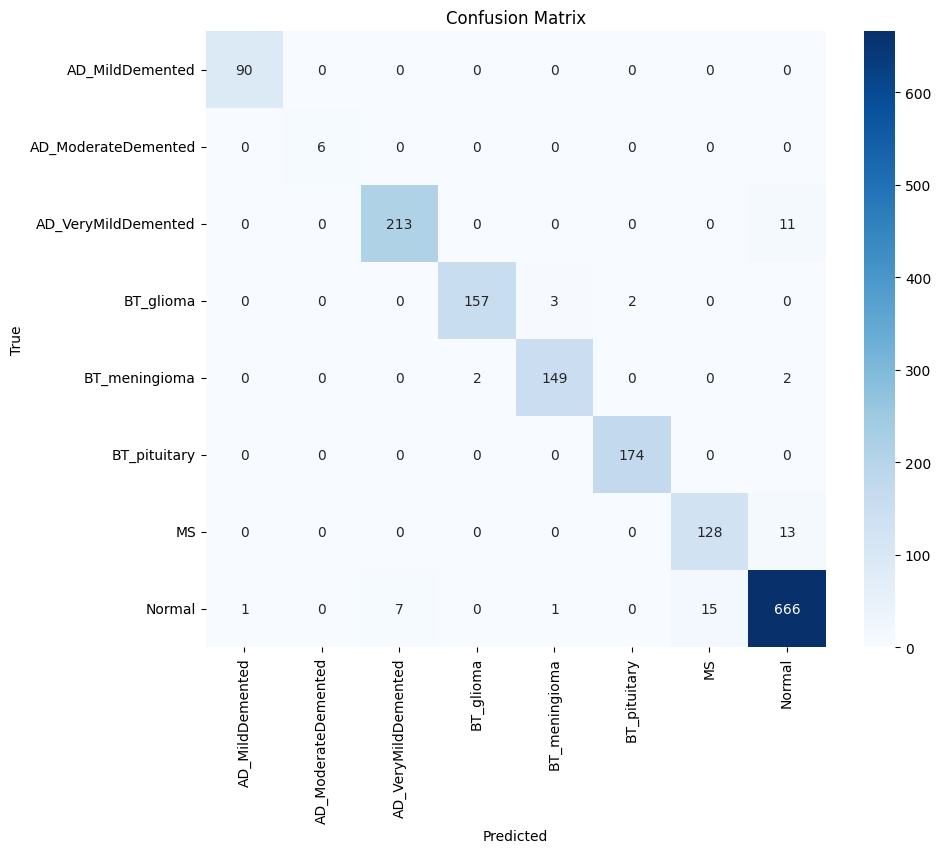

In [25]:
# Evaluate
test_loss, test_acc = model.evaluate(test_generator, steps=test_generator.samples // batch_size)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Per-class accuracy (confusion matrix)
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predict
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

# Report
print(classification_report(y_true, y_pred_classes, target_names=classes))

# Confusion Matrix Plot
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

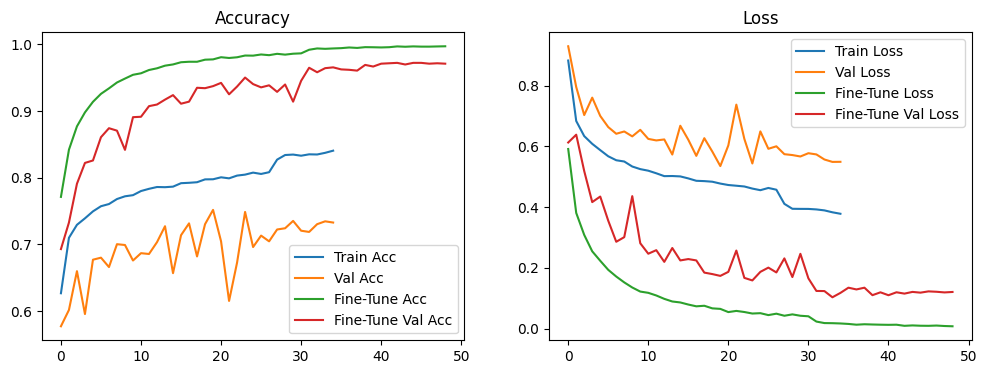

In [26]:
# Plot accuracy/loss curves
def plot_history(history, history_fine=None):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Acc')
    plt.plot(epochs_range, val_acc, label='Val Acc')
    if history_fine:
        plt.plot(history_fine.history['accuracy'], label='Fine-Tune Acc')
        plt.plot(history_fine.history['val_accuracy'], label='Fine-Tune Val Acc')
    plt.legend()
    plt.title('Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    if history_fine:
        plt.plot(history_fine.history['loss'], label='Fine-Tune Loss')
        plt.plot(history_fine.history['val_loss'], label='Fine-Tune Val Loss')
    plt.legend()
    plt.title('Loss')

    plt.show()

plot_history(history, history_fine)